#**Taller 3: Costrucción de un Modelo que prediga el precio de las casas en California empleando Algoritnos de 1. Arbol de Decisión, 2. Random Forest, 3.  Gradien Boosting, 4. Extreme Gradien Boosting, 5. Light Gradien Boosting**

In [12]:
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1 - Cargar Librerias

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
from sklearn import datasets, linear_model

# 2 - Cargar los Datos

In [ ]:
# En este ejercicio se usara un dataset disponible en las librería de sklearn
# de Caracteristicas y Precios de Casas en California

ds_california = datasets.fetch_california_housing()

https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_03_Dataset_California_Housing.csv



In [ ]:
# En este caso usaremos la dataset dispoible en la ruta github
ruta_dataset = "https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_03_Dataset_California_Housing.csv"

In [ ]:
df_california = pd.read_csv(ruta_dataset)

In [ ]:
type(df_california)

sklearn.utils._bunch.Bunch

In [ ]:
# La data de California esta en una estructura de tipo bunch.Bunch 
# Por lo que se debe mapear los datos a una estructura de tipo dataframe de pandas

# df_california = pd.DataFrame(ds_california.data, columns=ds_california.feature_names)

In [18]:
# En caso de que la dataset no este disponible en sklearn, 
# se puede cargar desde un archivo CSV del repositorio Github

# O en la ruta de github
# Dataset: https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_03_Dataset_California_Housing.csv

In [19]:
type(df_california)

pandas.DataFrame

In [20]:
# en caso de que la dataset no este disponible, puede usar el siguiente respaldo en github
# df_california = pd.read_csv('TALLER_03_Dataset_California_Housing.csv')

In [21]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')

In [ ]:
df_california['PRICE'] = df_california.target

NameError: name 'boston' is not defined

In [ ]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'PRICE'],
      dtype='object')

In [ ]:
#boston2 = datasets.fetch_openml(name='boston', version=1, as_frame=True)
#print("Boston dataset loaded successfully.")

In [ ]:
#type(boston2)

In [ ]:
df_california.shape

(20640, 9)

# 3 - Explorar los datos

In [ ]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


**MedInc:** Ingreso medio de los hogares en la zona.

**HouseAge:** Edad promedio de las casas en la zona.

**AveRooms**: Número promedio de habitaciones por vivienda.

**AveBedrms:** Número promedio de dormitorios por vivienda.

**Population:** Población total en la zona.

**AveOccup**: Número promedio de ocupantes por vivienda.

**Latitude:** Latitud geográfica de la zona.

**Longitude**: Longitud geográfica de la zona.

**PRICE**: Precio promedio de a vivienda.



# 4 - Dar tramiento a los datos crudos para obtener una Vista Minable

In [ ]:
# prompt: considera que se requiere realizar la limpieza de los datos del dataframe df_california, genera los comandos necesarios, evalua posibles datos perdiodos, presenta histograma de freecuencia y diagramas de cajas para detectar posible outliners

# 5 - Limpieza de datos
# Evaluar posibles datos perdidos
print("Missing values per column:")
print(df_california.isnull().sum())

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


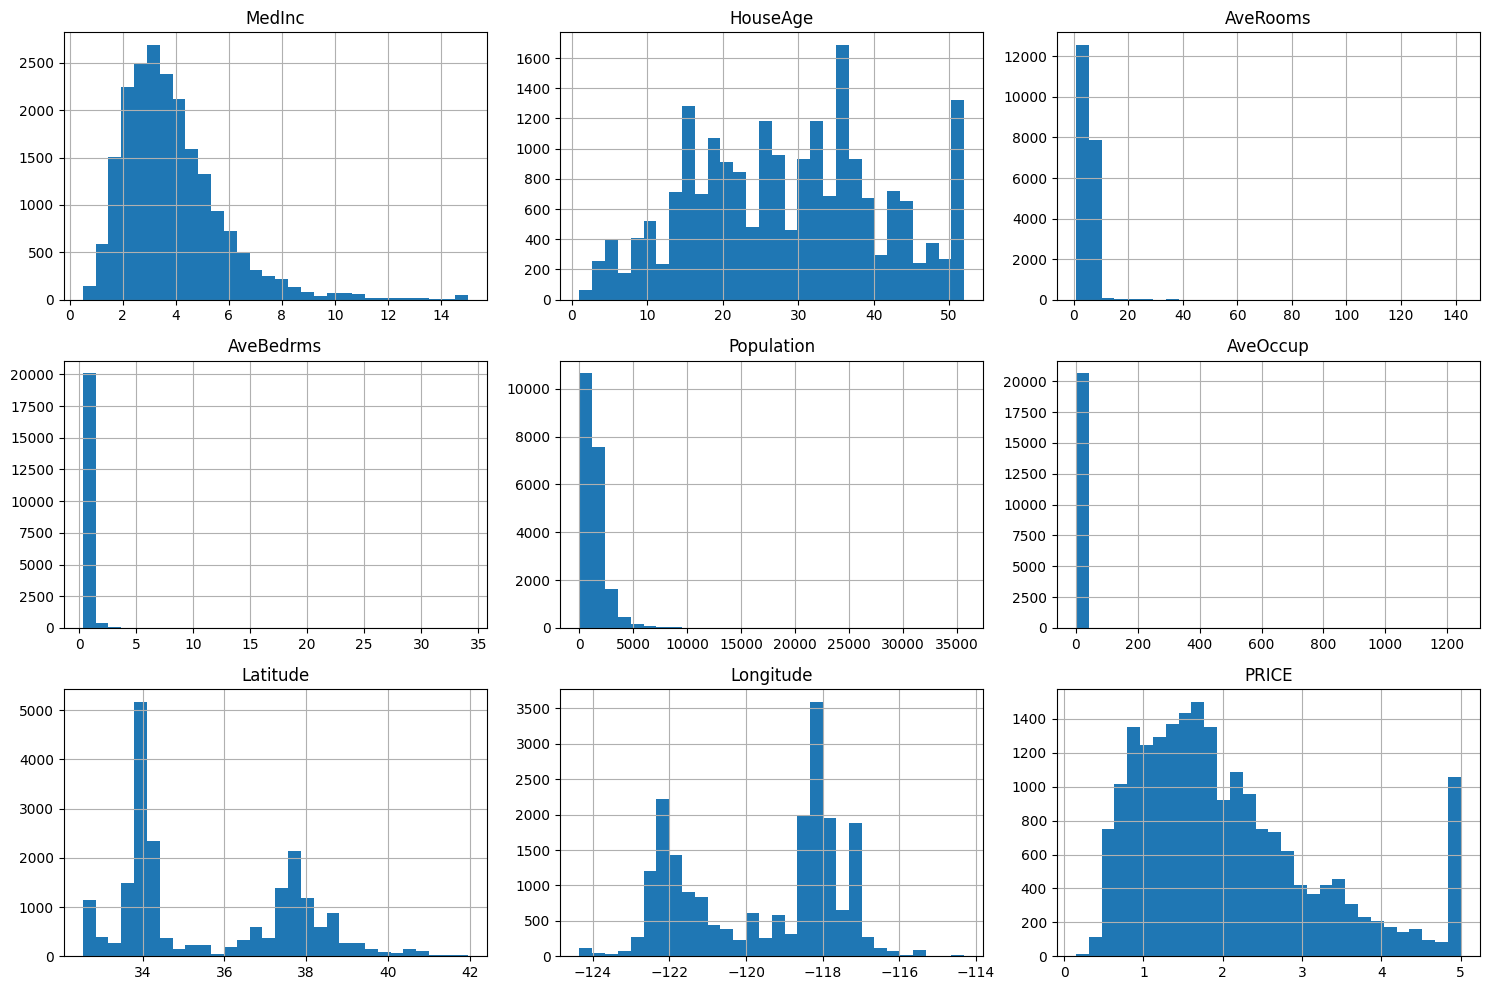

In [ ]:
# Histograma de frecuencia para cada columna para visualizar la distribución
df_california.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

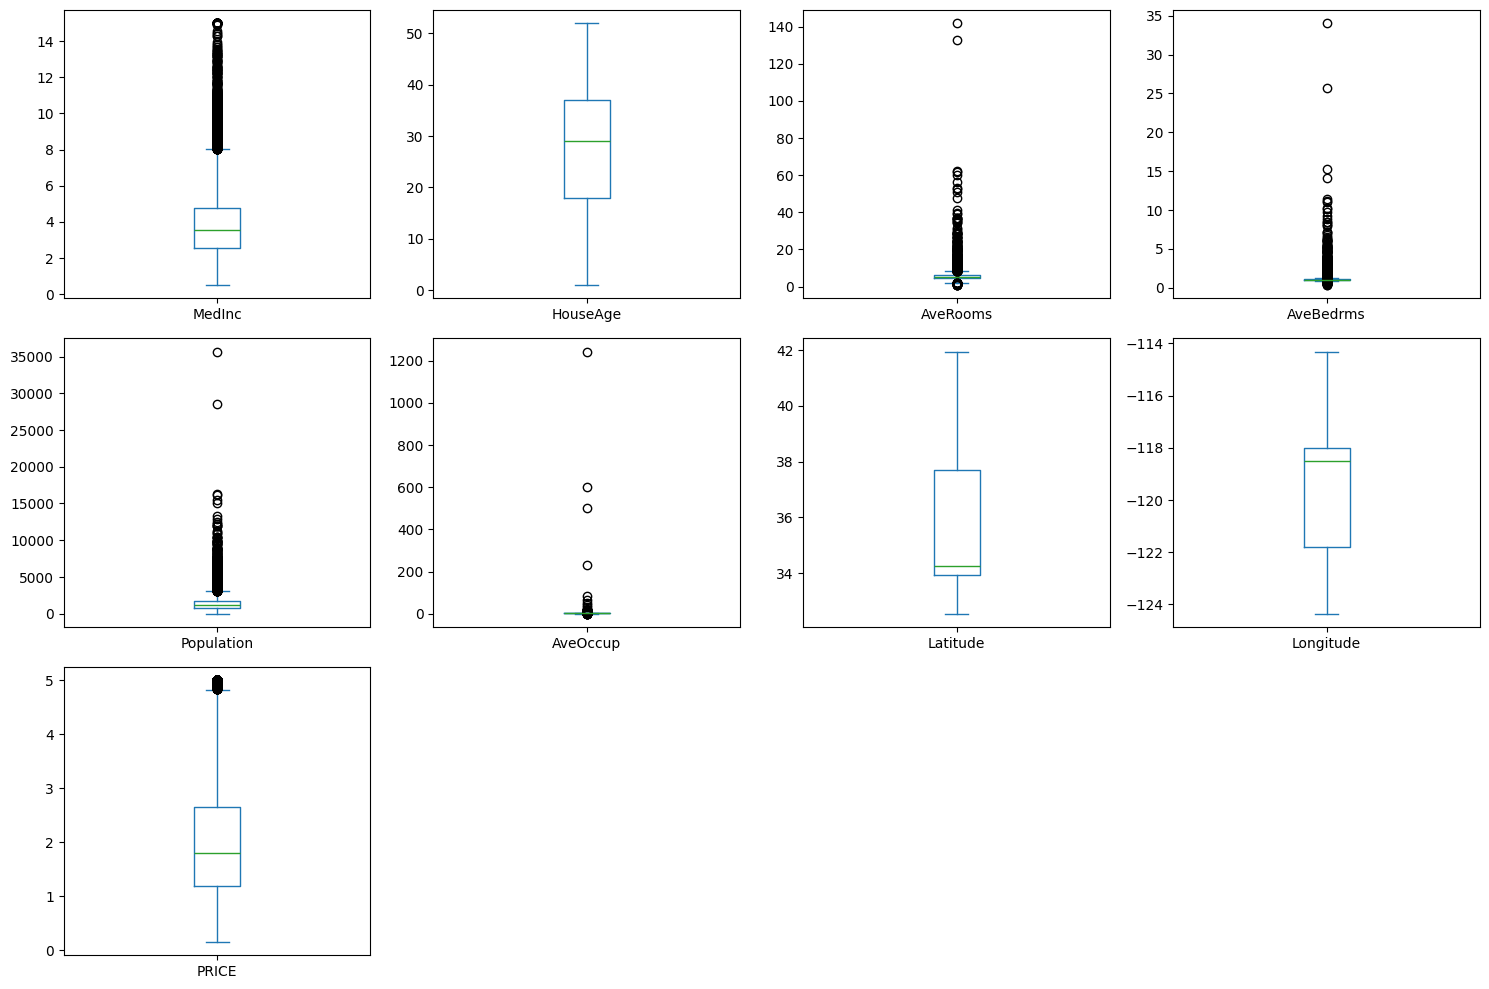

In [ ]:
# Diagramas de cajas para detectar posibles outliers
df_california.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

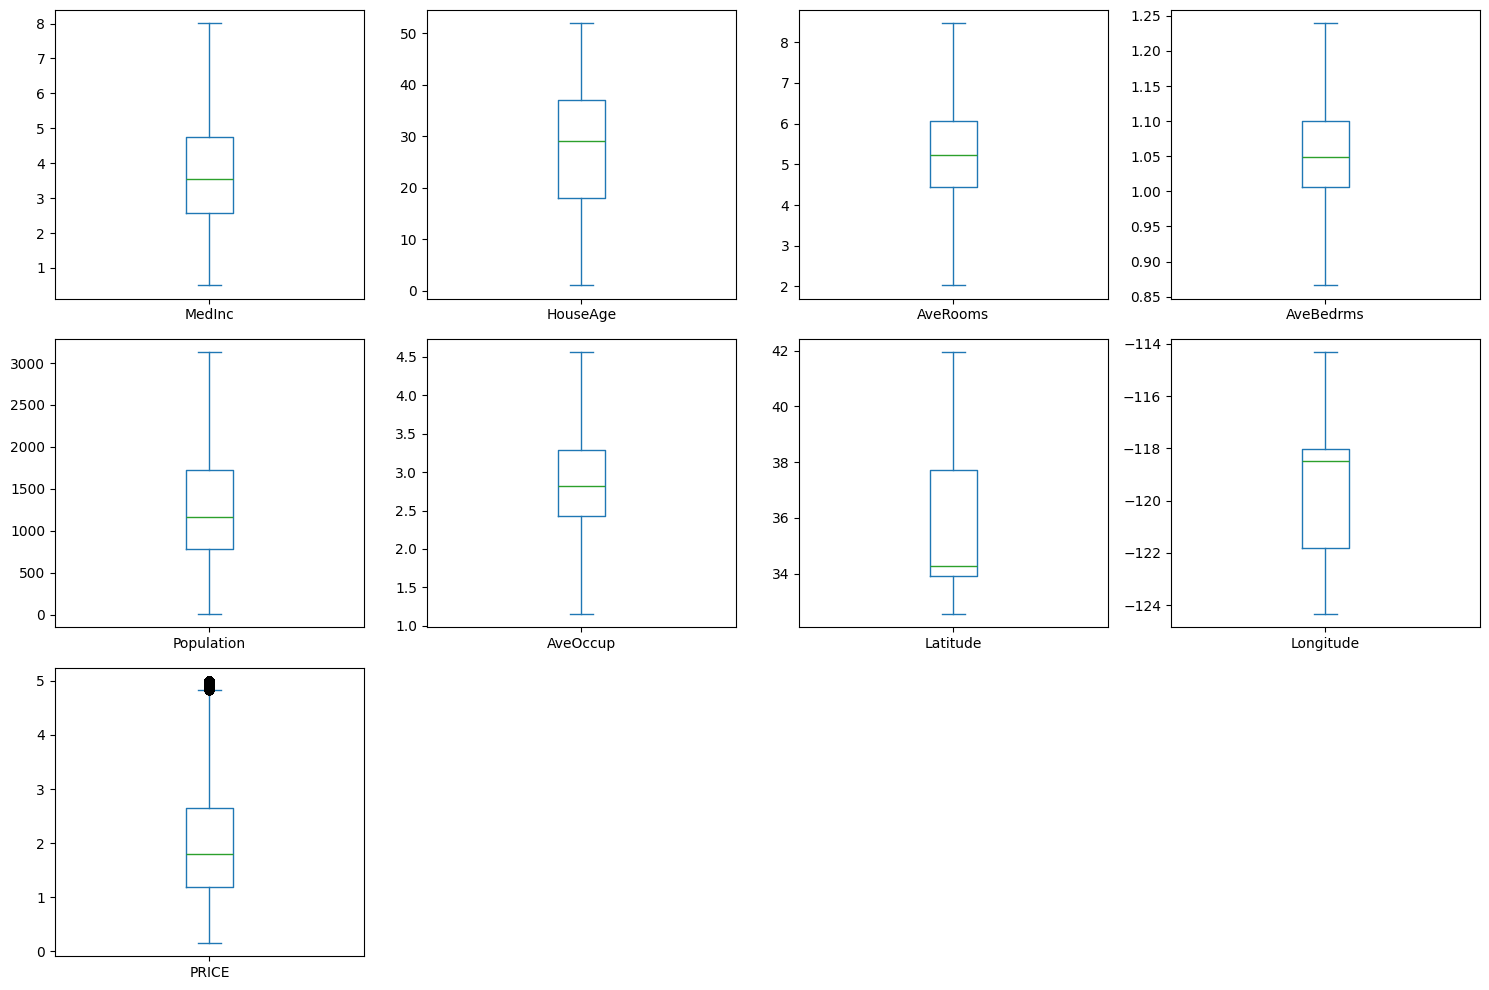

In [ ]:
# prompt: genera el codigo para corregir los outliers superiores e inferiores

# Función para corregir outliers usando el método del rango intercuartílico (IQR)
def correct_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - (1.5 * IQR)
  upper_bound = Q3 + (1.5 * IQR)

  # Reemplazar outliers por los límites (opcional: podrías usar la mediana, etc.)
  df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
  df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
  return df

# Aplicar la corrección de outliers a las columnas numéricas (excluyendo PRICE ya que es el objetivo)
for col in df_california.columns:
  if col != 'PRICE':
    df_california = correct_outliers_iqr(df_california, col)

# Mostrar diagramas de cajas después de la corrección para verificar
df_california.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


# 5 - Divir los datos en entrada (Xs) y salida (Y)

In [ ]:
# prompt: separa a price como columna 'Y' y reserva el 70% para entrenmiento y 30% para pruneas

from sklearn.model_selection import train_test_split

X = df_california.drop('PRICE', axis=1)
Y = df_california['PRICE']


#**6 - Dividir los datos en Entrenamiento (train) en Pruebas (test)**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (14448, 8)
Shape of X_test: (6192, 8)
Shape of Y_train: (14448,)
Shape of Y_test: (6192,)


#**7 - Crear el Modelo**

Modelo basado en Algoritmo de Arbol de Decisión pararesolver problema de Regresión

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Árbol de Decisión con profundidad máxima de 5 (poda)
modelo_dt = DecisionTreeRegressor(max_depth=5)

#**8 - Entrenar el Modelo Arbol de Decisión (Decision TREE)**

In [ ]:

modelo_dt.fit(X_train, Y_train)



DecisionTreeRegressor(max_depth=5)

#**9 - Predicción del Modelo**

In [ ]:
# Predicción
Y_pred_dt = modelo_dt.predict(X_test)

#**10 - Validacion de Calidad del modelo**

In [ ]:
# Evaluación
mse_dt = mean_squared_error(Y_test, Y_pred_dt)
r2_dt = r2_score(Y_test, Y_pred_dt)

print(f'MSE Árbol de Decisión (poda a 5 niveles): {mse_dt}')
print(f'R² Árbol de Decisión (poda a 5 niveles): {r2_dt}')


MSE Árbol de Decisión (poda a 5 niveles): 0.5204920738848303
R² Árbol de Decisión (poda a 5 niveles): 0.603446728380933


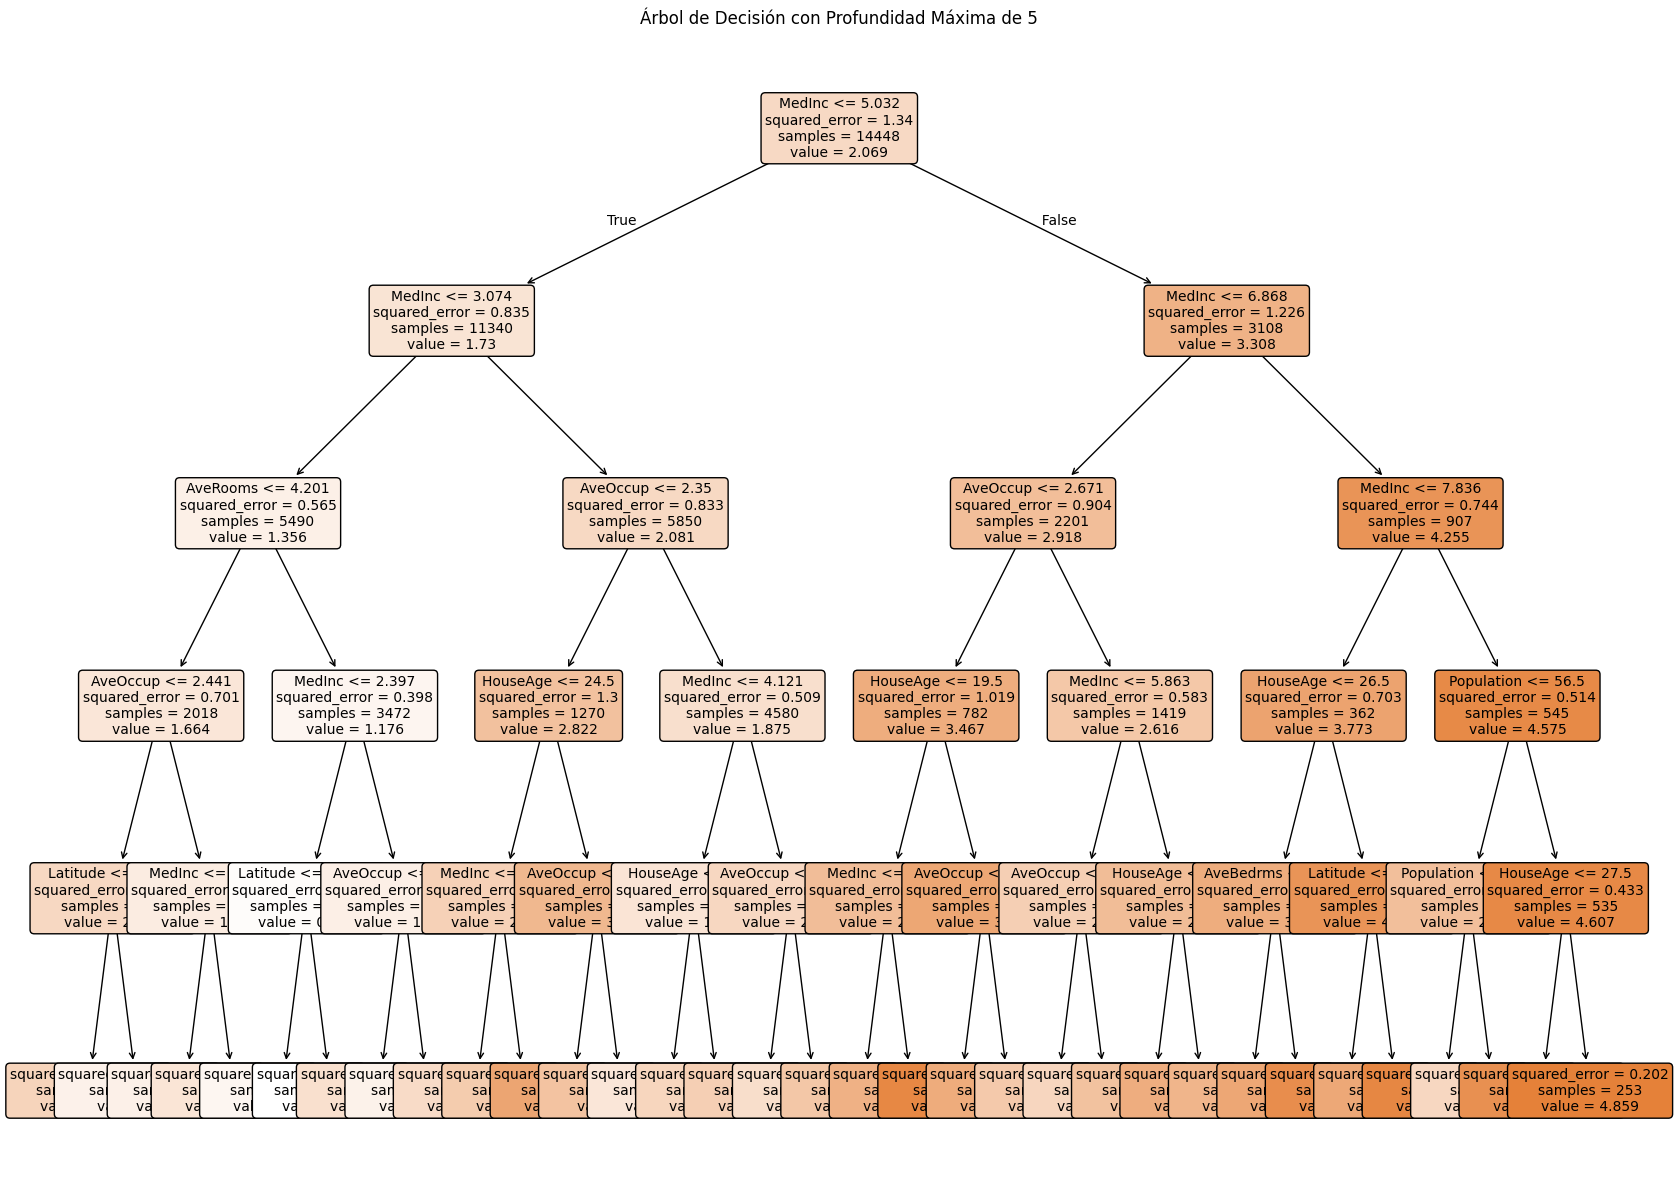

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
plot_tree(modelo_dt,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión con Profundidad Máxima de 5')
plt.show()

#**11 - Arbol a 6 niveles de profundidad**

In [ ]:
# Árbol de Decisión con profundidad máxima de 6 (poda)
modelo_dt_v6n = DecisionTreeRegressor(max_depth=6)

In [ ]:
# Entrenamiento
modelo_dt_v6n.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=6)

In [ ]:
# Predicción
Y_pred_dt_v6n = modelo_dt_v6n.predict(X_test)

In [ ]:
# Evaluación
mse_dt_v6n = mean_squared_error(Y_test, Y_pred_dt_v6n)
r2_dt_v6n = r2_score(Y_test, Y_pred_dt_v6n)

print(f'MSE Árbol de Decisión (poda a 6 niveles): {mse_dt_v6n}')
print(f'R² Árbol de Decisión (poda a 6 niveles): {r2_dt_v6n}')

MSE Árbol de Decisión (poda a 6 niveles): 0.4788435497000828
R² Árbol de Decisión (poda a 6 niveles): 0.6351779676297789


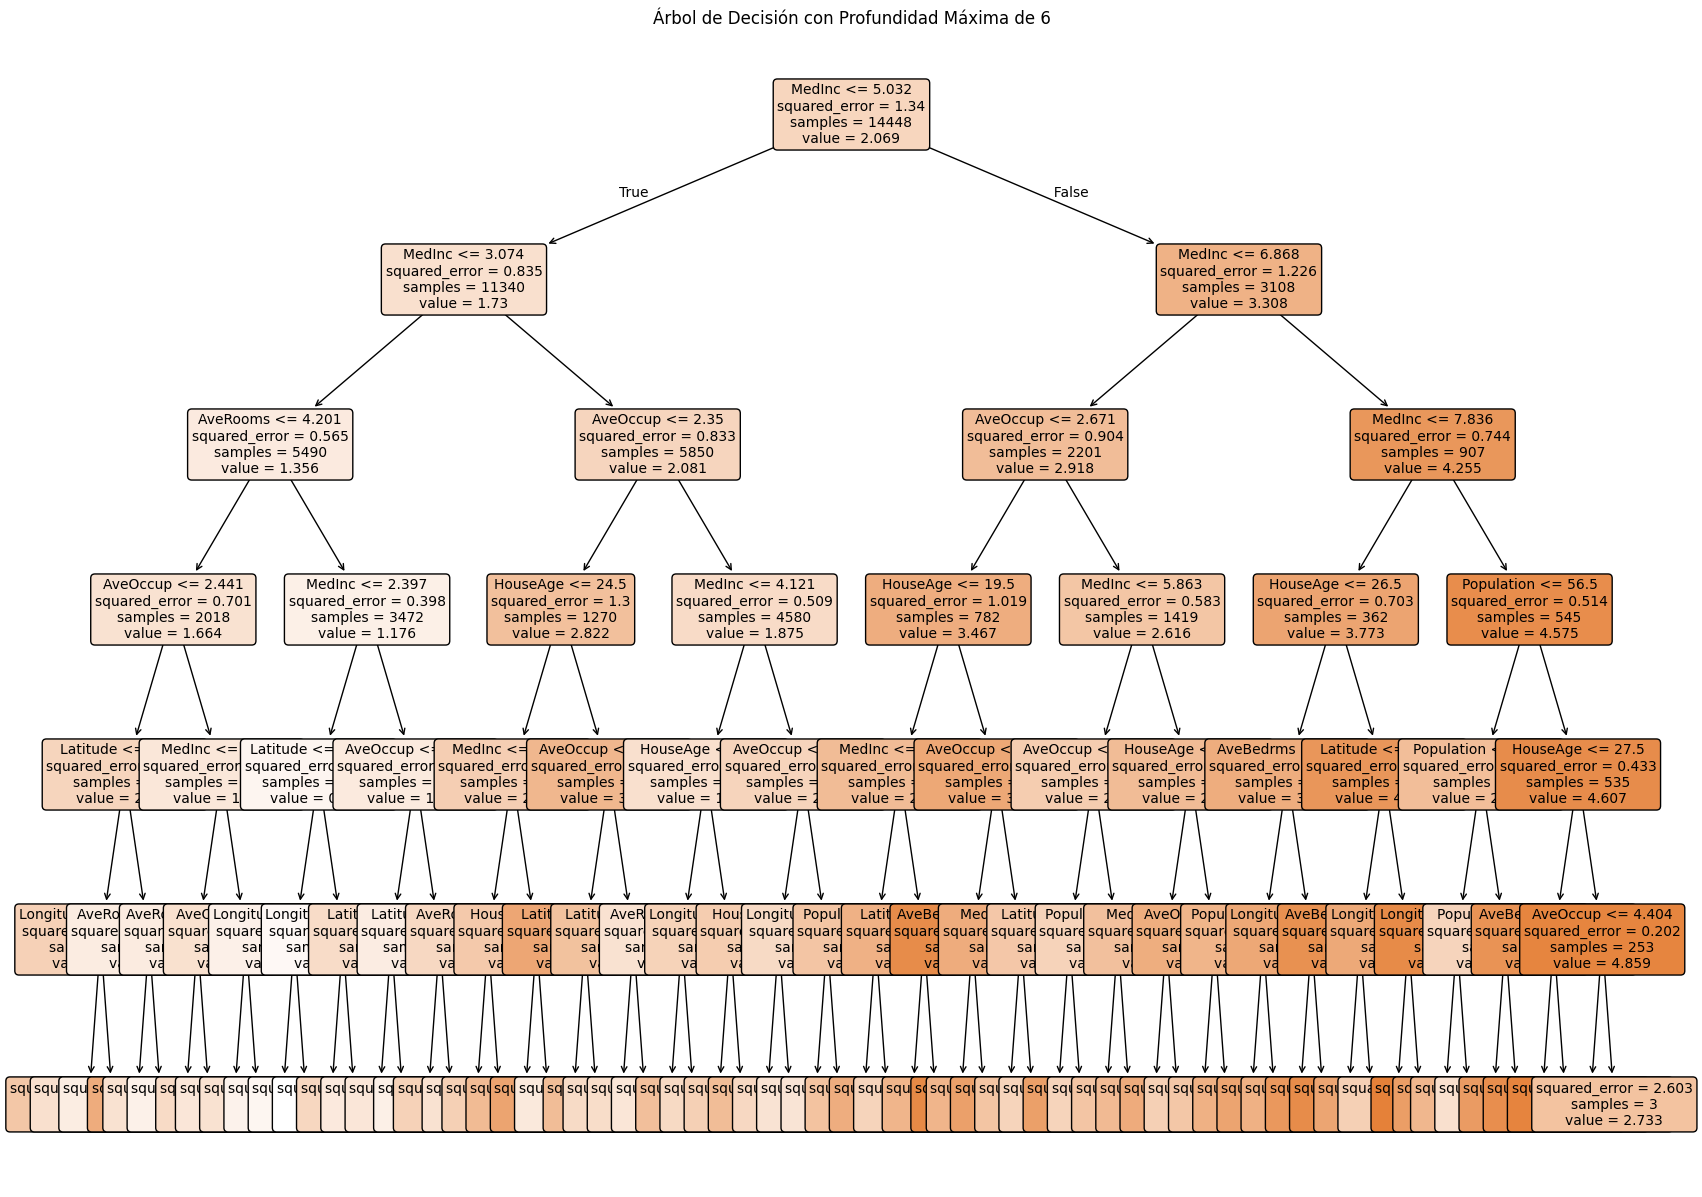

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
plot_tree(modelo_dt_v6n,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión con Profundidad Máxima de 6')
plt.show()

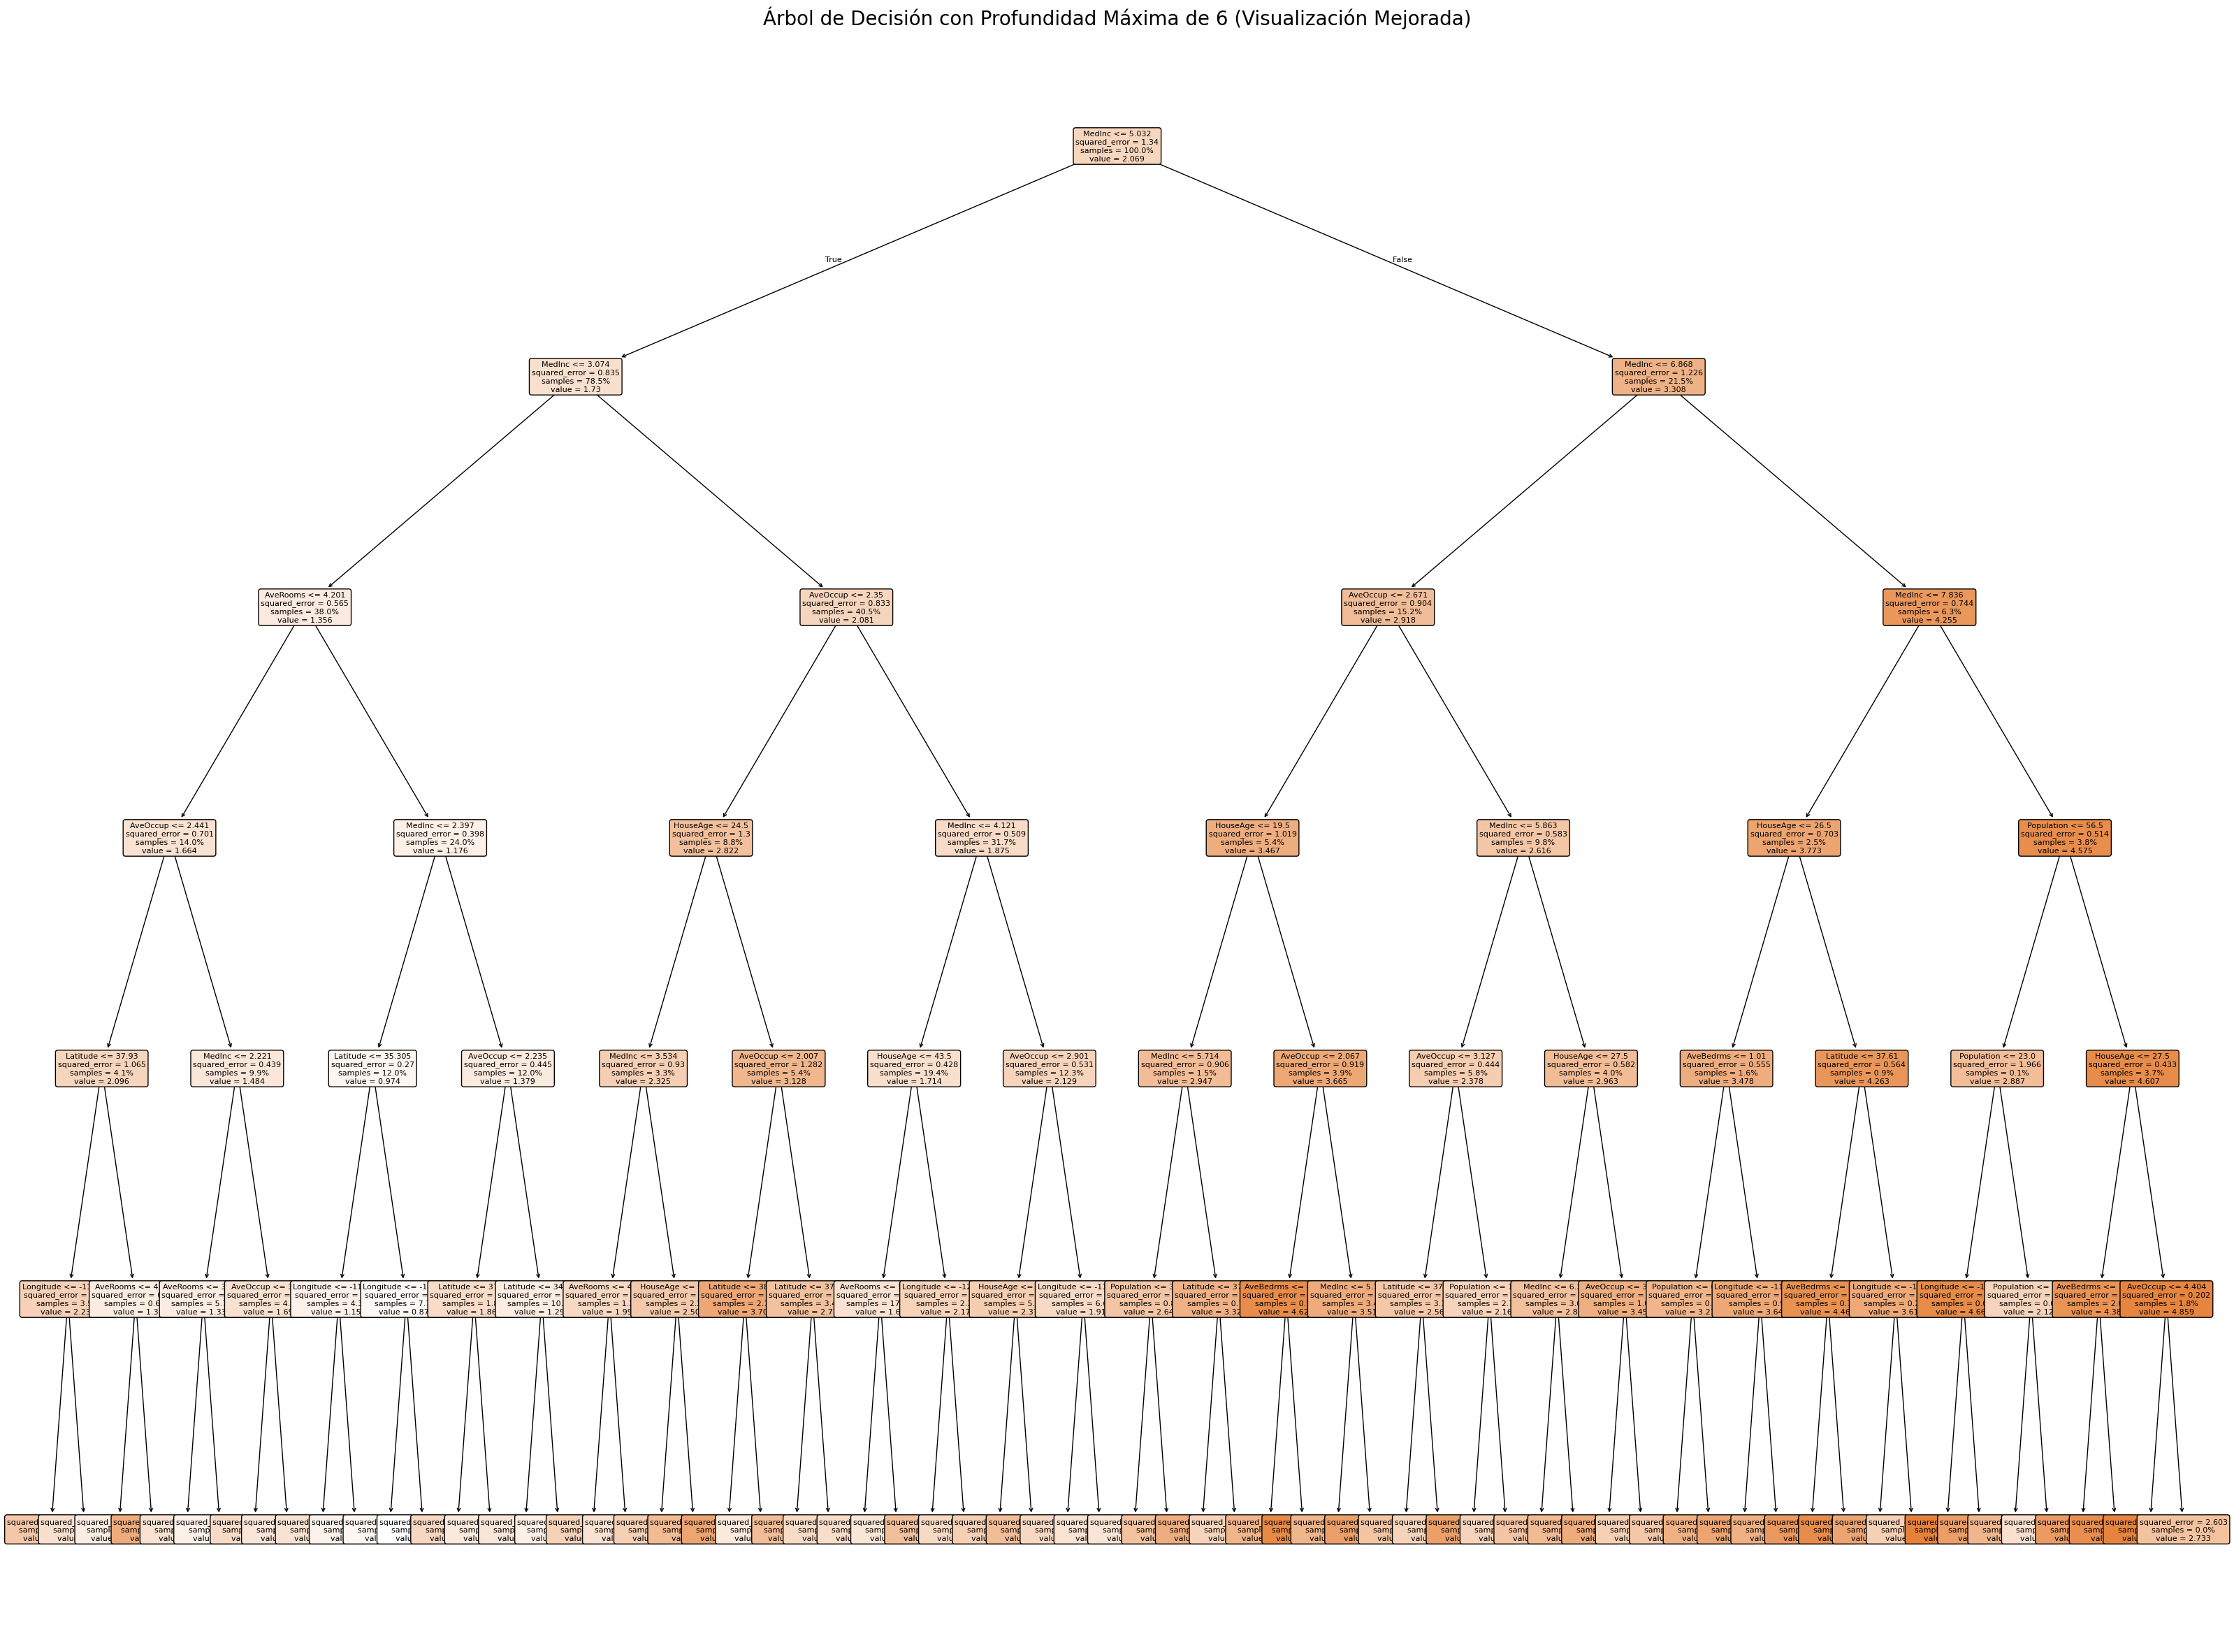

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,30)) # Increased figure size significantly
plot_tree(modelo_dt_v6n,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=8, # Adjusted fontsize to fit in larger figure
          proportion=True # Proportionally adjust node size
         )
plt.title('Árbol de Decisión con Profundidad Máxima de 6 (Visualización Mejorada)', fontsize=20)
plt.show()

#**11 - Arbol a 7 niveles de profundidad**

In [ ]:
# Árbol de Decisión con profundidad máxima de 6 (poda)
modelo_dt_v7n = DecisionTreeRegressor(max_depth=7)

In [ ]:
# Entrenamiento
modelo_dt_v7n.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=7)

In [ ]:
# Predicción
Y_pred_dt_v7n = modelo_dt_v7n.predict(X_test)

In [ ]:
# Evaluación
mse_dt_v7n = mean_squared_error(Y_test, Y_pred_dt_v7n)
r2_dt_v7n = r2_score(Y_test, Y_pred_dt_v7n)

print(f'MSE Árbol de Decisión (poda a 7 niveles): {mse_dt_v7n}')
print(f'R² Árbol de Decisión (poda a 7 niveles): {r2_dt_v7n}')

MSE Árbol de Decisión (poda a 7 niveles): 0.45593393584208985
R² Árbol de Decisión (poda a 7 niveles): 0.6526323781438702


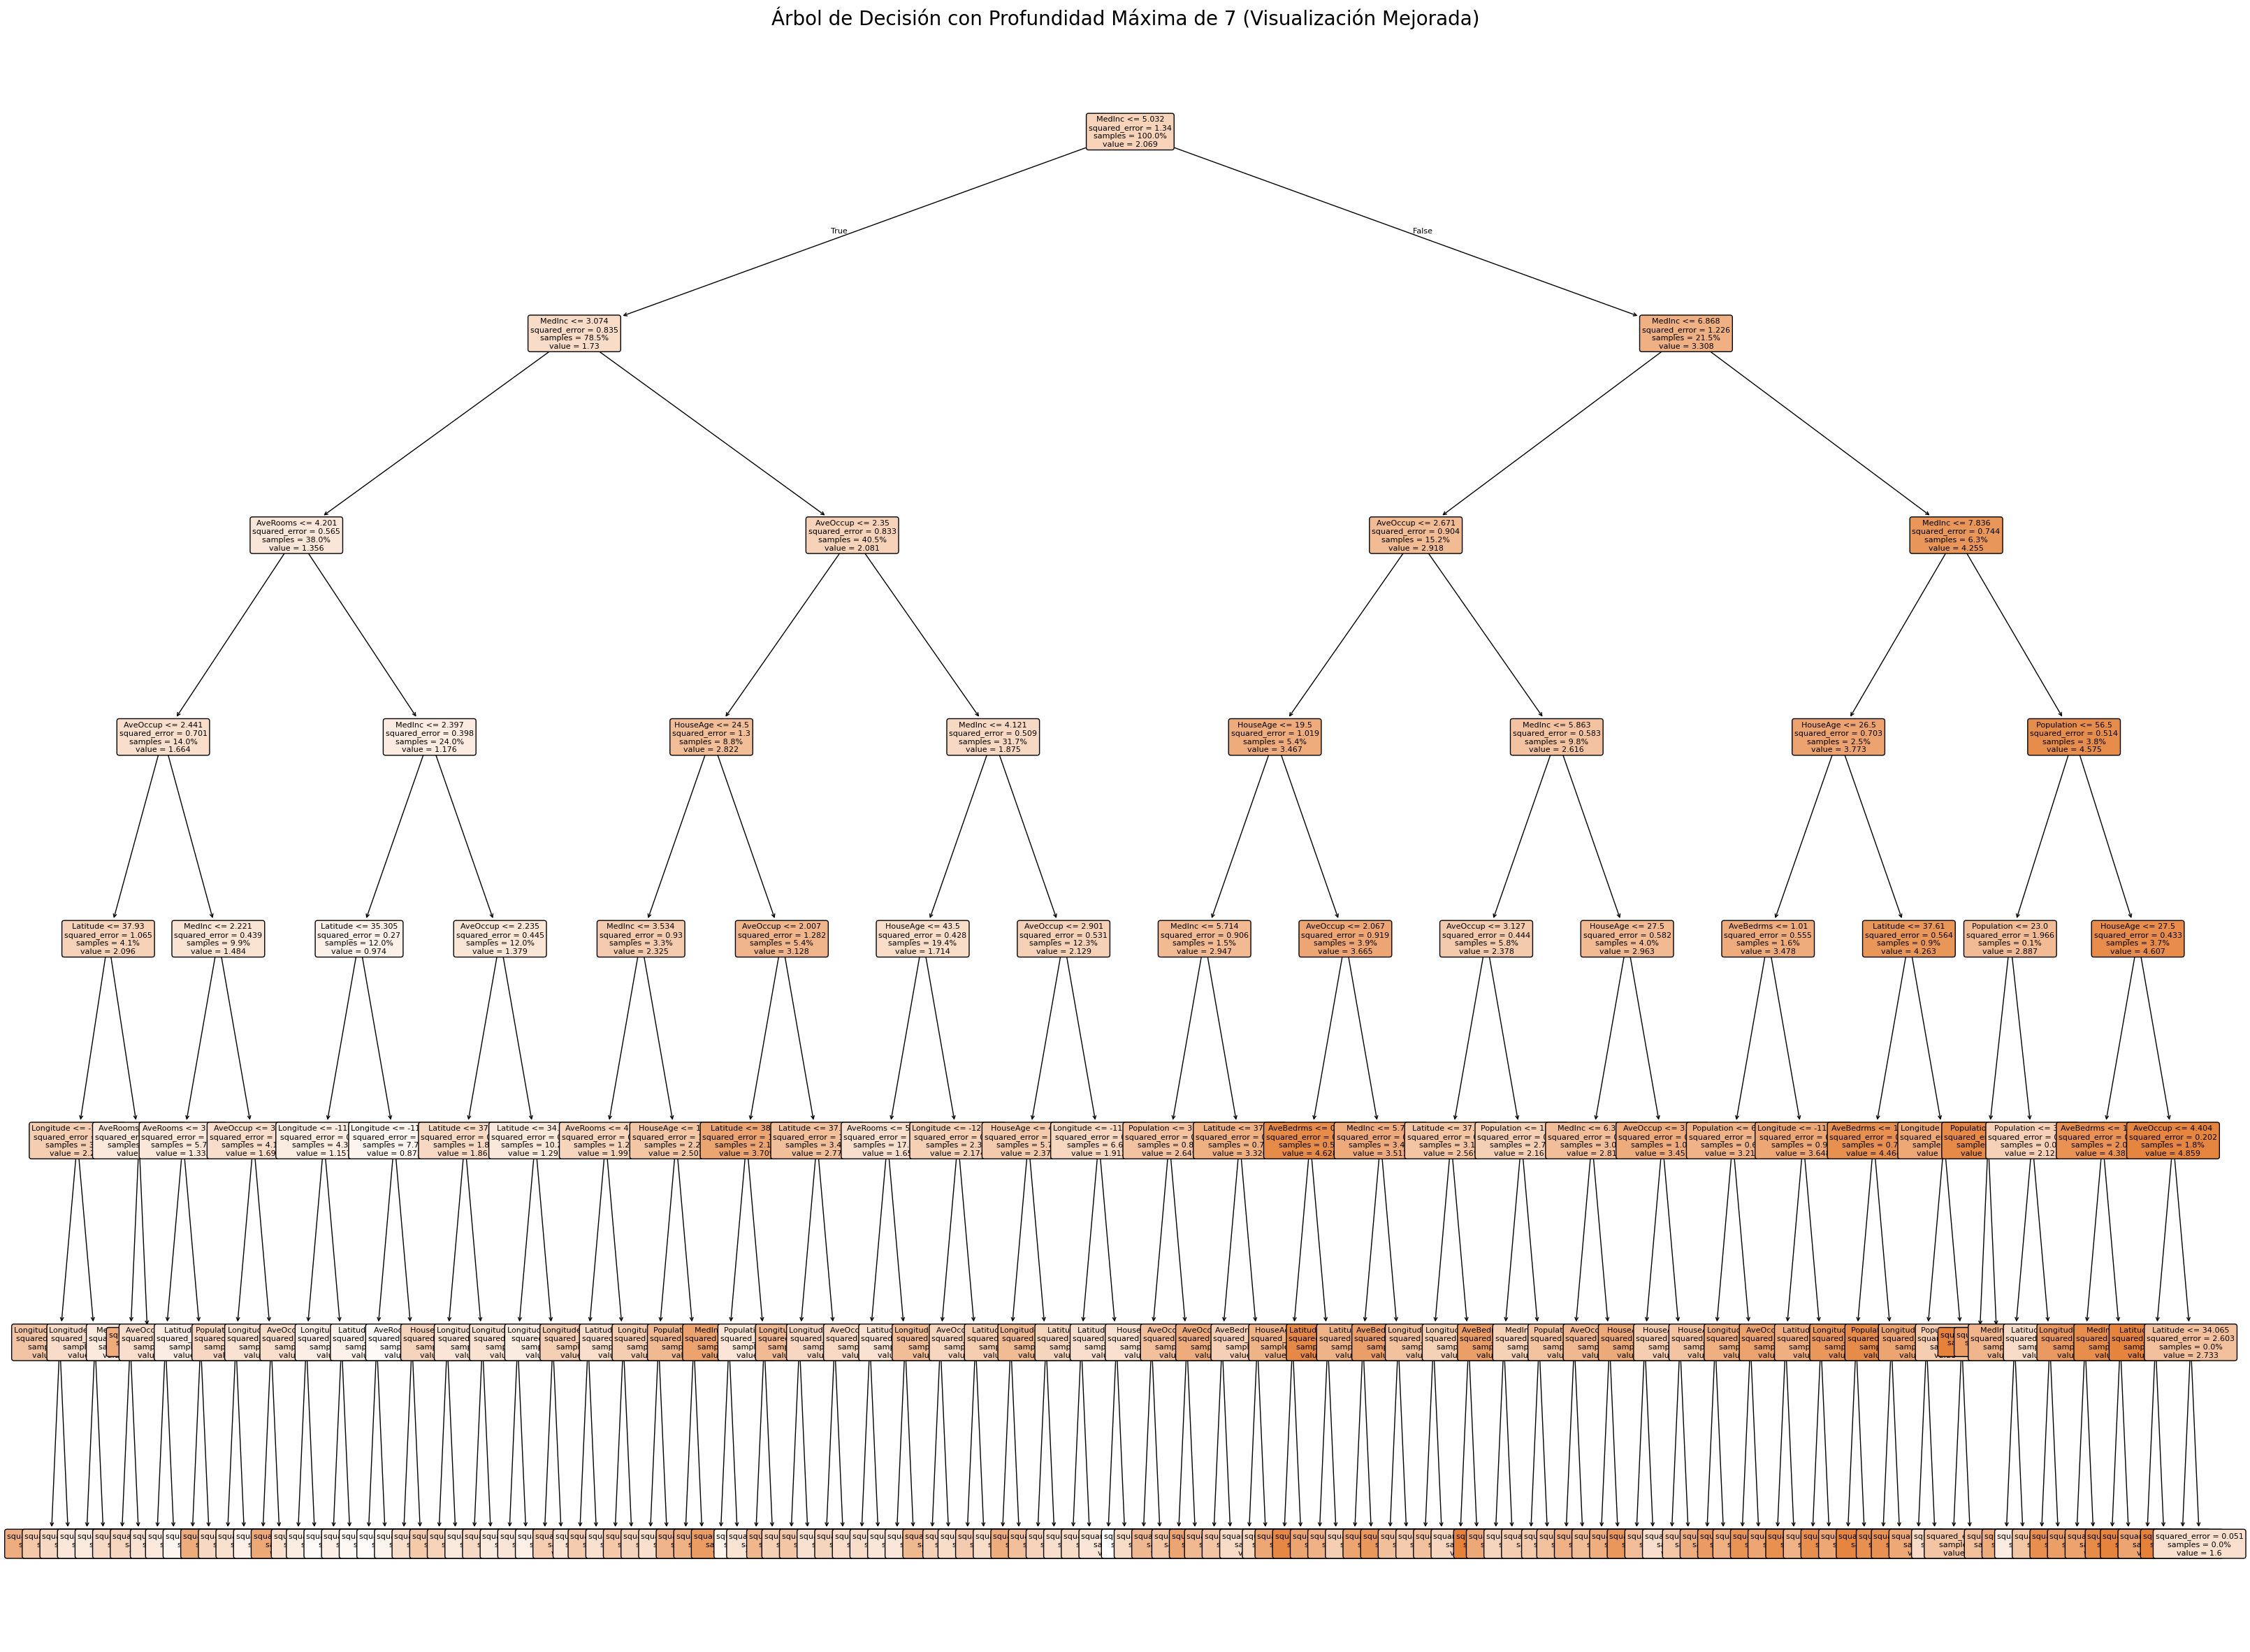

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,30)) # Increased figure size significantly
plot_tree(modelo_dt_v7n,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=8, # Adjusted fontsize to fit in larger figure
          proportion=True # Proportionally adjust node size
         )
plt.title('Árbol de Decisión con Profundidad Máxima de 7 (Visualización Mejorada)', fontsize=20)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 12 - Crear, Entrenar y Evaluar el Modelo Random Forest

# Crear el modelo Random Forest con 100 estimadores (bosquesitos)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenar el modelo
modelo_rf.fit(X_train, Y_train)

# Predicción
Y_pred_rf = modelo_rf.predict(X_test)

# Evaluación
mse_rf = mean_squared_error(Y_test, Y_pred_rf)
r2_rf = r2_score(Y_test, Y_pred_rf)

print(f'MSE Random Forest (100 estimadores): {mse_rf}')
print(f'R² Random Forest (100 estimadores): {r2_rf}')

MSE Random Forest (100 estimadores): 0.25753960695910044
R² Random Forest (100 estimadores): 0.8037853430718758


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Crear el modelo Gradient Boosting
modelo_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenar el modelo
modelo_gb.fit(X_train, Y_train)

# Predicción
Y_pred_gb = modelo_gb.predict(X_test)

# Evaluación
mse_gb = mean_squared_error(Y_test, Y_pred_gb)
r2_gb = r2_score(Y_test, Y_pred_gb)

print(f'MSE Gradient Boosting: {mse_gb}')
print(f'R² Gradient Boosting: {r2_gb}')

MSE Gradient Boosting: 0.2840169727820674
R² Gradient Boosting: 0.7836127284101668


In [ ]:
import xgboost as xgb

# Crear el modelo XGBoost
modelo_xgb = xgb.XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenar el modelo
modelo_xgb.fit(X_train, Y_train)

# Predicción
Y_pred_xgb = modelo_xgb.predict(X_test)

# Evaluación
mse_xgb = mean_squared_error(Y_test, Y_pred_xgb)
r2_xgb = r2_score(Y_test, Y_pred_xgb)

print(f'MSE XGBoost: {mse_xgb}')
print(f'R² XGBoost: {r2_xgb}')

MSE XGBoost: 0.22350388172835448
R² XGBoost: 0.8297165317861277


In [ ]:
# 15 - Modelo LightGBM
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

# Crear el modelo LightGBM
modelo_lgb = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42)

# Entrenar el modelo
modelo_lgb.fit(X_train, Y_train)

# Predicción
Y_pred_lgb = modelo_lgb.predict(X_test)

# Evaluación
mse_lgb = mean_squared_error(Y_test, Y_pred_lgb)
r2_lgb = r2_score(Y_test, Y_pred_lgb)

print(f'MSE LightGBM: {mse_lgb}')
print(f'R² LightGBM: {r2_lgb}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 8
[LightGBM] [Info] Start training from score 2.069240
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 